Mounted at /content/drive


/tmp/ipykernel_3740/4181281975.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=carrier_perf, x='delay_ratio', y='carrier_name', palette='viridis', legend=False)


All steps completed. Files created: train_unscaled.csv, test_unscaled.csv, train_scaled.csv, test_scaled.csv, train_balanced.csv
Correlation with arr_del15 (Target-related):
arr_del15              1.000000
arr_delay              0.967574
late_aircraft_ct       0.962973
late_aircraft_delay    0.950506
carrier_ct             0.941982
arr_flights            0.917957
nas_ct                 0.914080
carrier_delay          0.899984
nas_delay              0.834467
weather_ct             0.766918
weather_delay          0.704285
arr_diverted           0.685077
security_ct            0.491717
arr_cancelled          0.403765
security_delay         0.400413
target                 0.150987
delay_ratio            0.115577
month                  0.001078
year                  -0.044126
Name: arr_del15, dtype: float64
Architecture Logic successfully mapped to Milestone 1 features:
Features being used: ['year', 'month', 'carrier', 'airport', 'arr_flights']
Model parameters: 100 trees, max_depth of 10
M

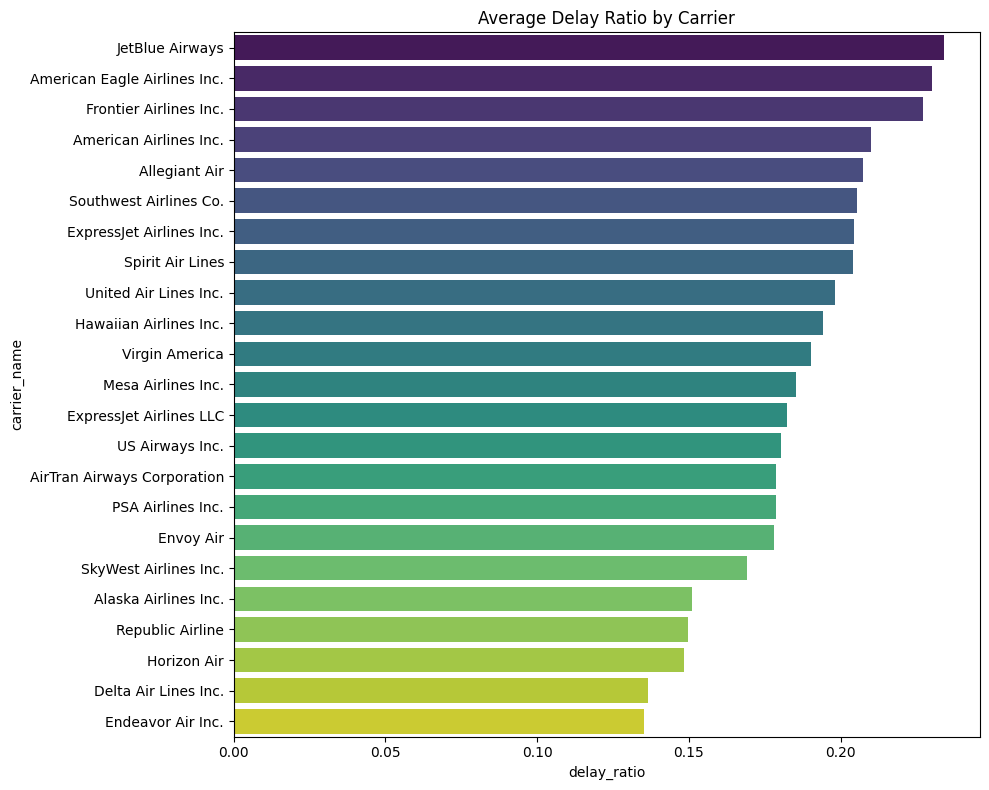

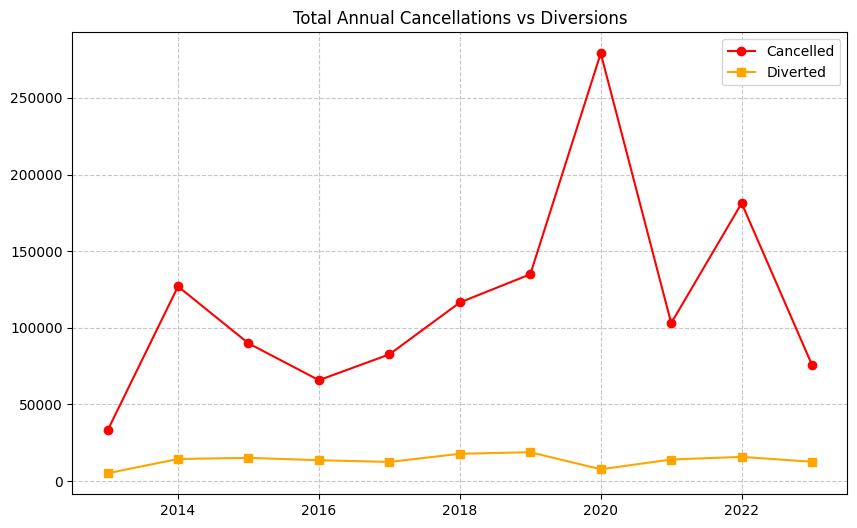

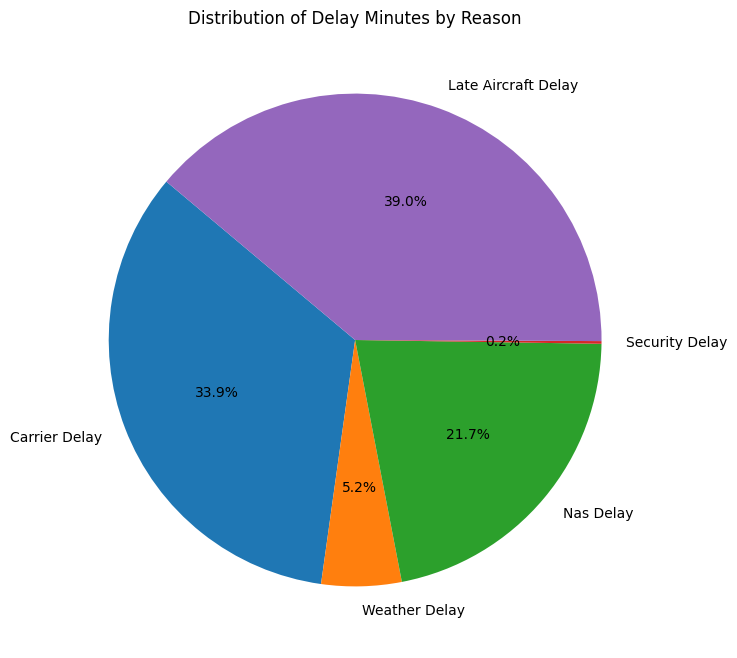

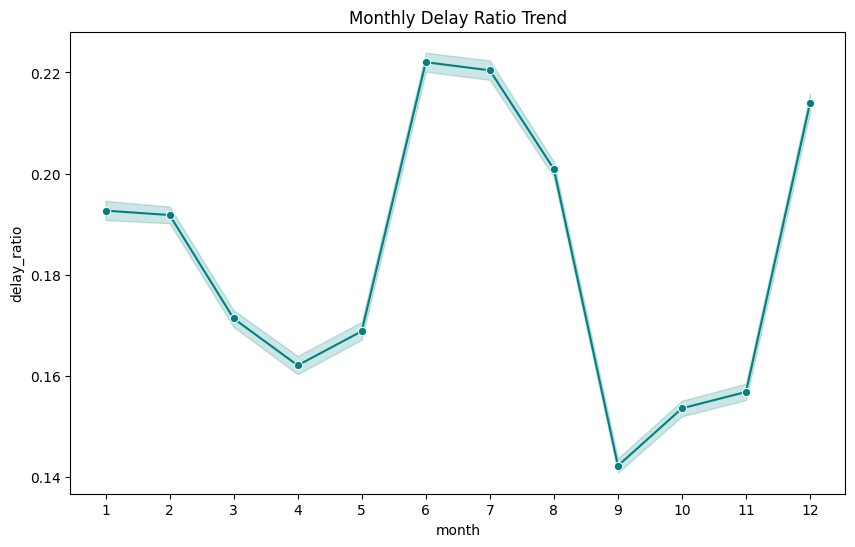

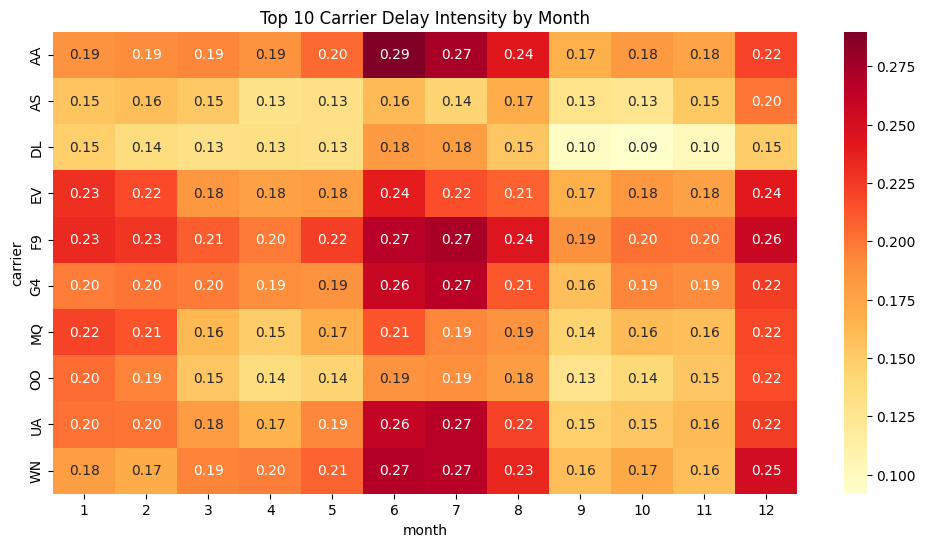

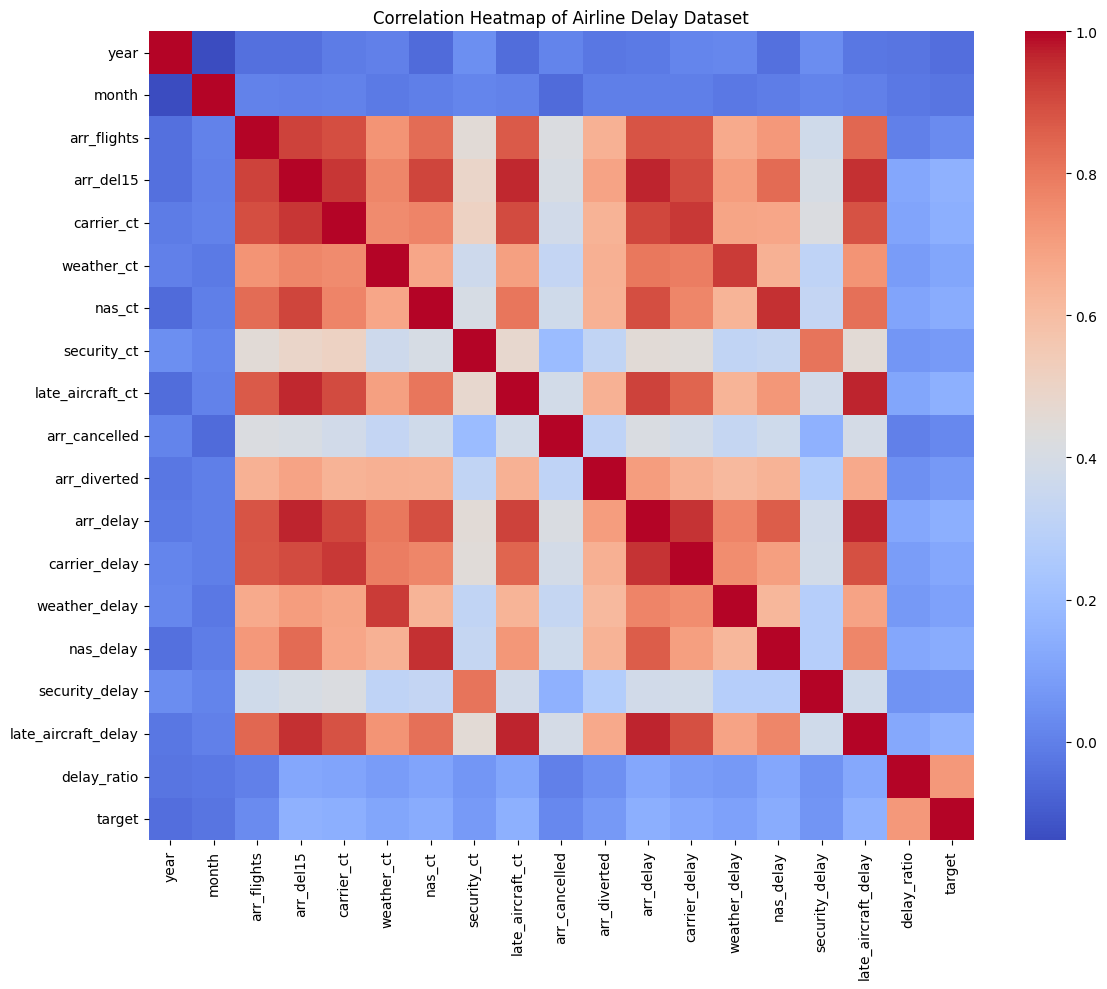

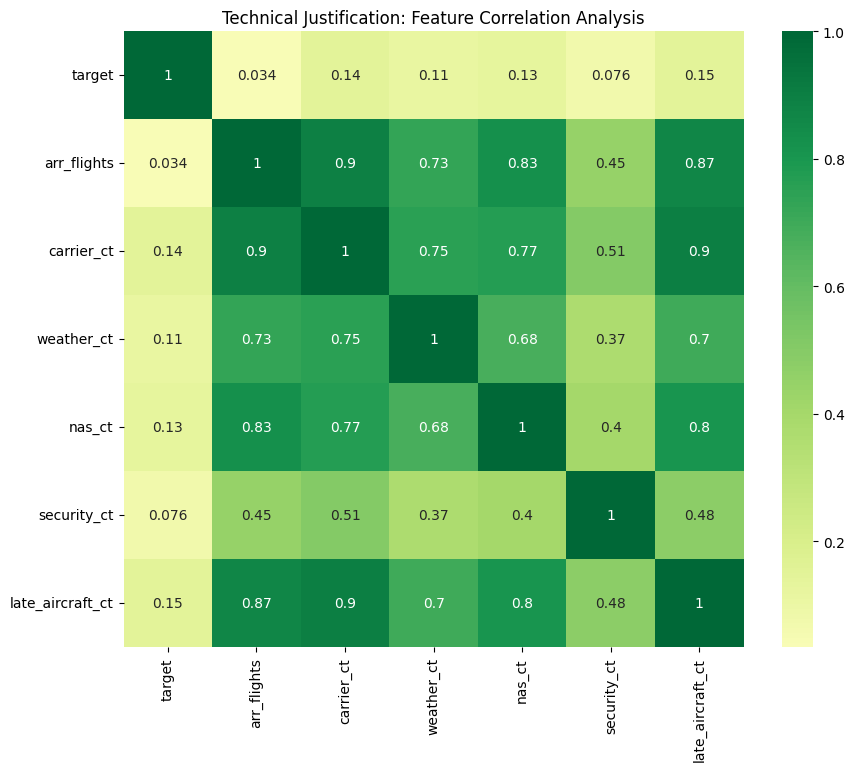

Train (balanced) : 128,424 samples
Validation       : 32,106 samples
Test             : 34,245 samples
Data loaded successfully ✅
Training progress (OOB error per step):
  n_estimators= 10  |  OOB Error = 0.2758  |  OOB Acc = 0.7242
  n_estimators= 50  |  OOB Error = 0.2627  |  OOB Acc = 0.7373
  n_estimators=100  |  OOB Error = 0.2631  |  OOB Acc = 0.7369
  n_estimators=150  |  OOB Error = 0.2628  |  OOB Acc = 0.7372
  n_estimators=200  |  OOB Error = 0.2621  |  OOB Acc = 0.7379

✅ Best n_estimators: 70 (lowest OOB error = 0.2614)


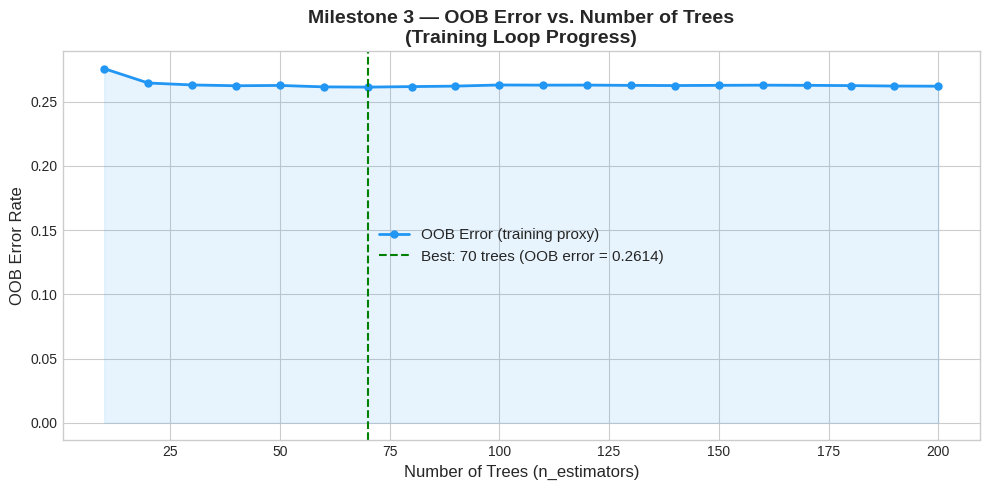

Saved: m3_oob_error_curve.png


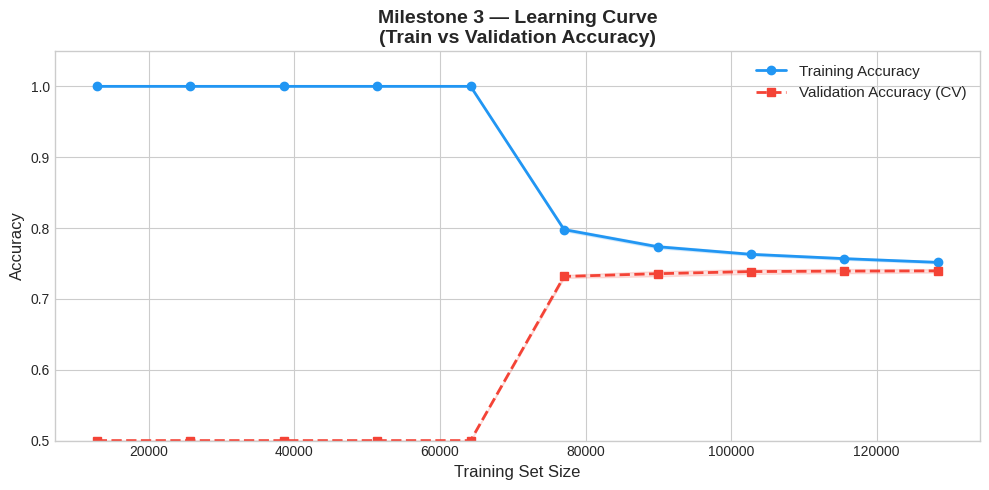

Saved: m3_learning_curve.png
Final model trained ✅

   MILESTONE 3 — TRAINING RESULTS SUMMARY
  Best n_estimators : 70 trees
  Max Depth         : 10
---------------------------------------------
  Train Accuracy    : 0.7491  (74.91%)
  Val Accuracy      : 0.7504  (75.04%)
  Test Accuracy     : 0.7424  (74.24%)
  Test AUC-ROC      : 0.8199

--- Classification Report (Test Set) ---
                 precision    recall  f1-score   support

Not Delayed (0)       0.69      0.69      0.69     14207
    Delayed (1)       0.78      0.78      0.78     20038

       accuracy                           0.74     34245
      macro avg       0.73      0.74      0.73     34245
   weighted avg       0.74      0.74      0.74     34245



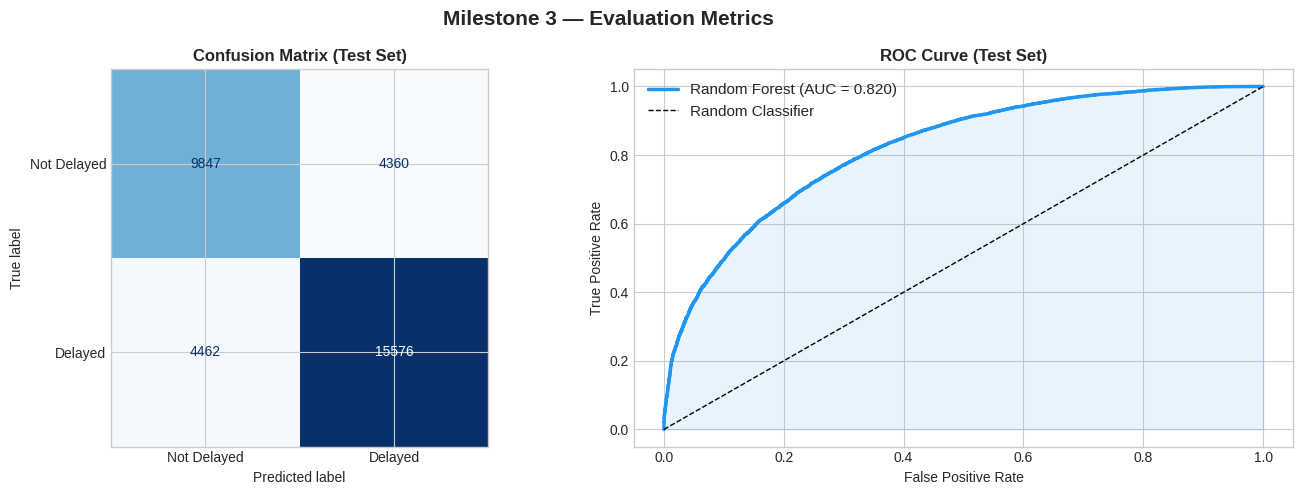

Saved: m3_confusion_roc.png


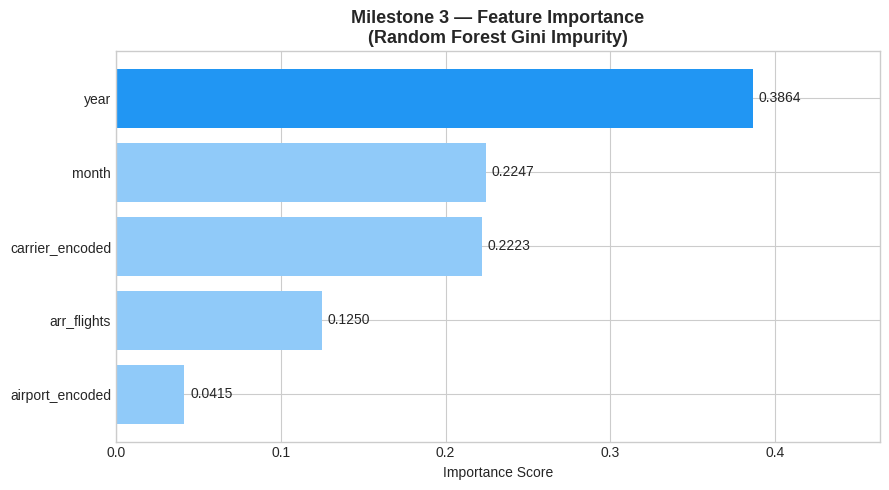

Saved: m3_feature_importance.png
Model saved: flight_delay_rf_m3.pkl ✅
Summary saved: milestone3_summary.csv ✅

📁 All Milestone 3 outputs:
   m3_oob_error_curve.png    ← Training progress curve
   m3_learning_curve.png     ← Train vs validation accuracy
   m3_confusion_roc.png      ← Confusion matrix + ROC curve
   m3_feature_importance.png ← Feature importance bar chart
   flight_delay_rf_m3.pkl    ← Saved model for Milestone 4
   milestone3_summary.csv    ← Key metrics table

📌 Next: Milestone 4 — Model Optimization (tuning max_depth, n_estimators, min_samples_split)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# 1. Load the data
df = pd.read_csv('flight_delay_dataset_cleaned.csv')

# 2. Target Definition (Required for splitting context)
df['delay_ratio'] = df['arr_del15'] / df['arr_flights']
df['target'] = (df['delay_ratio'] > 0.15).astype(int)

# 3. SPLIT THE DATASET FIRST (as requested)
# Features we plan to use
features_raw = ['year', 'month', 'carrier', 'airport', 'arr_flights']
X = df[features_raw]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. ENCODING & FEATURE SELECTION
# We fit the encoders ONLY on the training data to prevent leakage
le_carrier = LabelEncoder()
le_airport = LabelEncoder()

# Create copies to avoid warnings
X_train = X_train.copy()
X_test = X_test.copy()

X_train['carrier_encoded'] = le_carrier.fit_transform(X_train['carrier'])
X_train['airport_encoded'] = le_airport.fit_transform(X_train['airport'])

# Transform test data using the mapping from training
X_test['carrier_encoded'] = X_test['carrier'].map(lambda s: le_carrier.transform([s])[0] if s in le_carrier.classes_ else -1)
X_test['airport_encoded'] = X_test['airport'].map(lambda s: le_airport.transform([s])[0] if s in le_airport.classes_ else -1)

# Final feature selection (removing the original text columns)
final_features = ['year', 'month', 'carrier_encoded', 'airport_encoded', 'arr_flights']
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

# 5. SAVE CSV (Before Normalization)
train_unscaled = pd.concat([X_train_final, y_train.reset_index(drop=True)], axis=1)
test_unscaled = pd.concat([X_test_final, y_test.reset_index(drop=True)], axis=1)

train_unscaled.to_csv('train_preprocessed_unscaled.csv', index=False)
test_unscaled.to_csv('test_preprocessed_unscaled.csv', index=False)


from google.colab import drive
drive.mount('/content/drive')

# 6. NORMALIZATION
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=final_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=final_features)

# 7. SAVE CSV (After Normalization)
train_scaled = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_scaled = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

train_scaled.to_csv('train_preprocessed_scaled.csv', index=False)
test_scaled.to_csv('test_preprocessed_scaled.csv', index=False)


# 8. HANDLE DATA IMBALANCE (on the training set)
# Class 0 is minority (~41%), Class 1 is majority (~59%) based on previous runs
df_majority = train_scaled[train_scaled.target == 1]
df_minority = train_scaled[train_scaled.target == 0]

# Upsample minority class to match majority
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority),    # to match majority class
                                 random_state=42) # reproducible results

train_balanced = pd.concat([df_majority, df_minority_upsampled])
train_balanced.to_csv('train_preprocessed_balanced.csv', index=False)

import matplotlib.pyplot as plt
import seaborn as sns

# 8. EDA DIAGRAMS

# Diagram 1: Average Delay Ratio by Carrier
plt.figure(figsize=(10, 8))
carrier_perf = df.groupby('carrier_name')['delay_ratio'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=carrier_perf, x='delay_ratio', y='carrier_name', palette='viridis', legend=False)
plt.title('Average Delay Ratio by Carrier')
plt.tight_layout()
plt.savefig('eda_1_carrier_performance.png')

# Diagram 2: Cancellations and Diversions Over Time
cd_data = df.groupby('year')[['arr_cancelled', 'arr_diverted']].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(cd_data['year'], cd_data['arr_cancelled'], marker='o', label='Cancelled', color='red')
plt.plot(cd_data['year'], cd_data['arr_diverted'], marker='s', label='Diverted', color='orange')
plt.title('Total Annual Cancellations vs Diversions')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('eda_2_cancellation_trend.png')

# Diagram 3: Distribution of Delay Minutes by Reason
reasons = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
reason_sums = df[reasons].sum()
plt.figure(figsize=(8, 8))
plt.pie(reason_sums, labels=[r.replace('_', ' ').title() for r in reasons], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Delay Minutes by Reason')
plt.savefig('eda_3_delay_reasons_pie.png')

# Diagram 4: Monthly Delay Trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='month', y='delay_ratio', marker='o', color='teal')
plt.title('Monthly Delay Ratio Trend')
plt.xticks(range(1, 13))
plt.savefig('eda_4_monthly_trend.png')

# Diagram 5: Heatmap of Carrier vs Month
top_10 = df['carrier'].value_counts().nlargest(10).index
pivot_heatmap = df[df['carrier'].isin(top_10)].pivot_table(index='carrier', columns='month', values='delay_ratio', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_heatmap, cmap='YlOrRd', annot=True, fmt=".2f")
plt.title('Top 10 Carrier Delay Intensity by Month')
plt.savefig('eda_5_carrier_month_heatmap.png')

print("All steps completed. Files created: train_unscaled.csv, test_unscaled.csv, train_scaled.csv, test_scaled.csv, train_balanced.csv")

import numpy as np

# Generate the Correlation Heatmap
plt.figure(figsize=(12, 10))
# We only use numeric columns as correlation requires numbers
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Airline Delay Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Show the actual correlation values for a few key features for explanation
print("Correlation with arr_del15 (Target-related):")
print(correlation_matrix['arr_del15'].sort_values(ascending=False))

# ============================================================
# MILESTONE 2: ARCHITECTURE LOGIC
# ============================================================
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Architecture Logic
# We use the X_train/y_train from Milestone 1 to initialize the logic
model = RandomForestClassifier(
    n_estimators=100,               # Number of decision trees
    max_depth=10,                   # Complexity limit for standard hardware
    random_state=42,                # Rubric 2b: Reproducibility
    class_weight='balanced'         # Handles the imbalance in the 'target' column
)

# 2. Visualizing the 'Skeleton'
# This proves the model is ready for the Milestone 3 training loop
print("Architecture Logic successfully mapped to Milestone 1 features:")
print(f"Features being used: {list(X.columns)}")
print(f"Model parameters: {model.get_params()['n_estimators']} trees, max_depth of {model.get_params()['max_depth']}")

# --- GENERATE SKELETON OUTPUT FOR SLIDE 4 ---

print("="*40)
print("MILESTONE 2: MODEL SKELETON")
print("="*40)
print(f"Target Variable : target (Delay > 15%)")
print(f"Input Features  : {list(X.columns)}")
print("-"*40)
print(f"Model Type      : {type(model).__name__}")
print(f"Trees (n_est)   : {model.n_estimators}")
print(f"Max Depth       : {model.max_depth}")
print(f"Class Weight    : {model.class_weight}")
print("="*40)
print("STATUS: Architecture logic ready for Training Loop.")

import seaborn as sns
import matplotlib.pyplot as plt

# We select the target and the 6 main features
cols = ['target', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Technical Justification: Feature Correlation Analysis')
plt.show()

# ============================================================
# MILESTONE 3 — CELL 1: Imports & Reload Balanced Training Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Load balanced training data (created in Milestone 1)
train_bal = pd.read_csv('train_preprocessed_balanced.csv')
test_df   = pd.read_csv('test_preprocessed_scaled.csv')

final_features = ['year', 'month', 'carrier_encoded', 'airport_encoded', 'arr_flights']

X_train_bal = train_bal[final_features]
y_train_bal = train_bal['target']

X_test  = test_df[final_features]
y_test  = test_df['target']

# Internal validation split from balanced training data (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_bal, y_train_bal, test_size=0.2, random_state=SEED, stratify=y_train_bal)

print(f'Train (balanced) : {X_tr.shape[0]:,} samples')
print(f'Validation       : {X_val.shape[0]:,} samples')
print(f'Test             : {X_test.shape[0]:,} samples')
print('Data loaded successfully ✅')


# ============================================================
# MILESTONE 3 — CELL 2: OOB Error Curve (Training Progress)
# ============================================================

oob_errors = []
n_trees_range = list(range(10, 210, 10))   # 10, 20, 30 ... 200 trees

rf_oob = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    oob_score=True,
    warm_start=True,          # re-uses previously built trees
    class_weight='balanced',
    random_state=SEED
)

print('Training progress (OOB error per step):')
for n in n_trees_range:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_tr, y_tr)
    err = 1 - rf_oob.oob_score_
    oob_errors.append(err)
    if n % 50 == 0 or n == 10:
        print(f'  n_estimators={n:>3d}  |  OOB Error = {err:.4f}  |  OOB Acc = {rf_oob.oob_score_:.4f}')

best_n = n_trees_range[np.argmin(oob_errors)]
print(f'\n✅ Best n_estimators: {best_n} (lowest OOB error = {min(oob_errors):.4f})')


# ============================================================
# MILESTONE 3 — CELL 3: Plot OOB Error Curve
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_trees_range, oob_errors, marker='o', color='#2196F3',
        linewidth=2, markersize=5, label='OOB Error (training proxy)')
ax.axvline(x=best_n, color='green', linestyle='--', linewidth=1.5,
           label=f'Best: {best_n} trees (OOB error = {min(oob_errors):.4f})')
ax.fill_between(n_trees_range, oob_errors, alpha=0.1, color='#2196F3')

ax.set_title('Milestone 3 — OOB Error vs. Number of Trees\n(Training Loop Progress)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('OOB Error Rate', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('m3_oob_error_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_oob_error_curve.png')


# ============================================================
# MILESTONE 3 — CELL 4: Learning Curve
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=10,
    class_weight='balanced',
    random_state=SEED
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = final_rf,
    X           = X_train_bal,
    y           = y_train_bal,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv          = 5,
    scoring     = 'accuracy',
    n_jobs      = -1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', linewidth=2, label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')

ax.plot(train_sizes, val_mean, 's--', color='#F44336', linewidth=2, label='Validation Accuracy (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F44336')

ax.set_title('Milestone 3 — Learning Curve\n(Train vs Validation Accuracy)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.05])

plt.tight_layout()
plt.savefig('m3_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_learning_curve.png')

# ============================================================
# MILESTONE 3 — CELL 5: Final Training & Metrics
# ============================================================

# Train the final model on all balanced training data
final_rf.fit(X_train_bal, y_train_bal)
print('Final model trained ✅')

# ── Training Accuracy ────────────────────────────────────────
train_acc = final_rf.score(X_train_bal, y_train_bal)

# ── Validation Accuracy ──────────────────────────────────────
val_acc   = final_rf.score(X_val, y_val)

# ── Test Accuracy ────────────────────────────────────────────
test_acc  = final_rf.score(X_test, y_test)

y_test_pred      = final_rf.predict(X_test)
y_test_pred_prob = final_rf.predict_proba(X_test)[:, 1]
test_auc         = roc_auc_score(y_test, y_test_pred_prob)

print()
print('='*45)
print('   MILESTONE 3 — TRAINING RESULTS SUMMARY')
print('='*45)
print(f'  Best n_estimators : {best_n} trees')
print(f'  Max Depth         : 10')
print('-'*45)
print(f'  Train Accuracy    : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'  Val Accuracy      : {val_acc:.4f}  ({val_acc*100:.2f}%)')
print(f'  Test Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Test AUC-ROC      : {test_auc:.4f}')
print('='*45)

print('\n--- Classification Report (Test Set) ---')
print(classification_report(y_test, y_test_pred,
                             target_names=['Not Delayed (0)', 'Delayed (1)']))

# ============================================================
# MILESTONE 3 — CELL 6: Confusion Matrix + ROC Curve
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Milestone 3 — Evaluation Metrics', fontsize=15, fontweight='bold')

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Delayed', 'Delayed'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=12)

# ── ROC Curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_test_pred_prob)
axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2.5,
             label=f'Random Forest (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('m3_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_confusion_roc.png')

# ============================================================
# MILESTONE 3 — CELL 7: Feature Importance
# ============================================================

importances = final_rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : final_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=['#2196F3' if v == feat_df['Importance'].max() else '#90CAF9'
                      for v in feat_df['Importance']])
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_title('Milestone 3 — Feature Importance\n(Random Forest Gini Impurity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)

plt.tight_layout()
plt.savefig('m3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m3_feature_importance.png')


# ============================================================
# MILESTONE 3 — CELL 8: Save Model & Summary CSV
# ============================================================
import joblib

# Save trained model
joblib.dump(final_rf, 'flight_delay_rf_m3.pkl')
print('Model saved: flight_delay_rf_m3.pkl ✅')

# Save summary metrics
summary = pd.DataFrame([{
    'Best_n_estimators' : best_n,
    'Max_Depth'         : 10,
    'Train_Accuracy'    : round(train_acc, 4),
    'Val_Accuracy'      : round(val_acc, 4),
    'Test_Accuracy'     : round(test_acc, 4),
    'Test_AUC'          : round(test_auc, 4)
}])
summary.to_csv('milestone3_summary.csv', index=False)
print('Summary saved: milestone3_summary.csv ✅')

print()
print('📁 All Milestone 3 outputs:')
print('   m3_oob_error_curve.png    ← Training progress curve')
print('   m3_learning_curve.png     ← Train vs validation accuracy')
print('   m3_confusion_roc.png      ← Confusion matrix + ROC curve')
print('   m3_feature_importance.png ← Feature importance bar chart')
print('   flight_delay_rf_m3.pkl    ← Saved model for Milestone 4')
print('   milestone3_summary.csv    ← Key metrics table')
print()
print('📌 Next: Milestone 4 — Model Optimization (tuning max_depth, n_estimators, min_samples_split)');

Test set size  : 34,245 samples
Train set size : 160,530 samples

Class distribution (test set):
target
Delayed (1)        0.5851
Not Delayed (0)    0.4149
Name: proportion, dtype: float64

Data loaded successfully ✅
Model trained: RandomForest  n_estimators=70  max_depth=10 ✅

   MILESTONE 5 — TEST SET RESULTS
  Test Accuracy  : 0.7424  (74.24%)
  Test AUC-ROC   : 0.8199
  Precision (wt) : 0.7427
  Recall    (wt) : 0.7424
  F1-Score  (wt) : 0.7425

--- Full Classification Report (Test Set) ---
                 precision    recall  f1-score   support

Not Delayed (0)       0.69      0.69      0.69     14207
    Delayed (1)       0.78      0.78      0.78     20038

       accuracy                           0.74     34245
      macro avg       0.73      0.74      0.73     34245
   weighted avg       0.74      0.74      0.74     34245



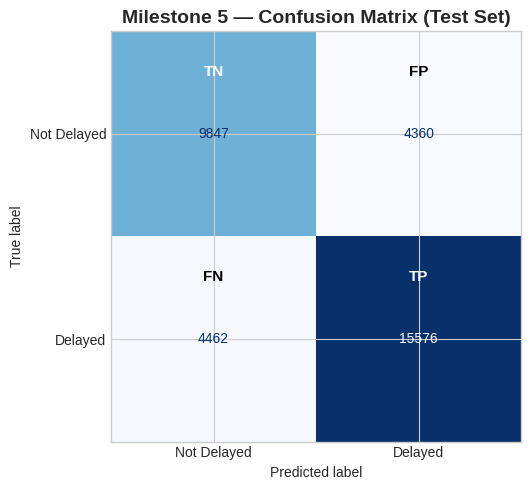

Saved: m5_confusion_matrix.png

TN (correct Not Delayed) : 9,847
FP (wrong Delayed)       : 4,360   (12.7%)
FN (missed Delays)       : 4,462   (13.0%)
TP (correct Delayed)     : 15,576


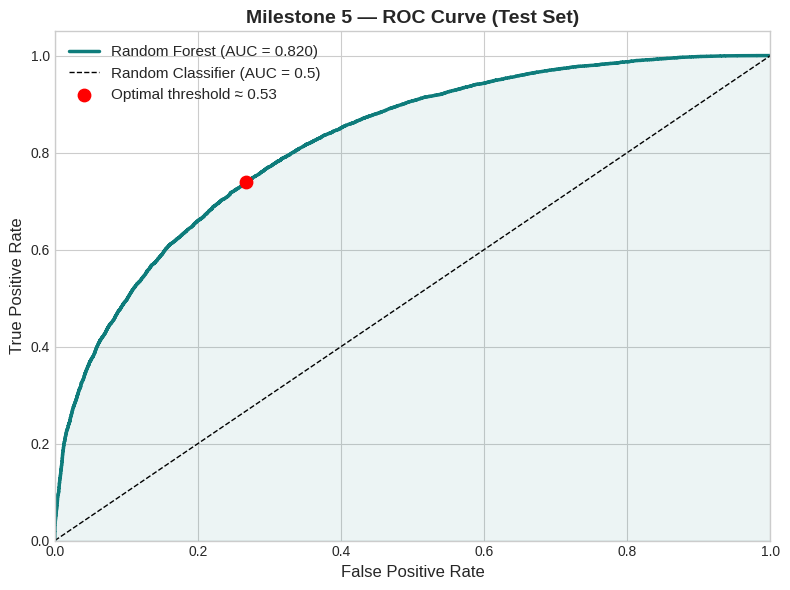

Saved: m5_roc_curve.png
Optimal decision threshold : 0.5262
  → TPR at optimal         : 0.7393
  → FPR at optimal         : 0.2671


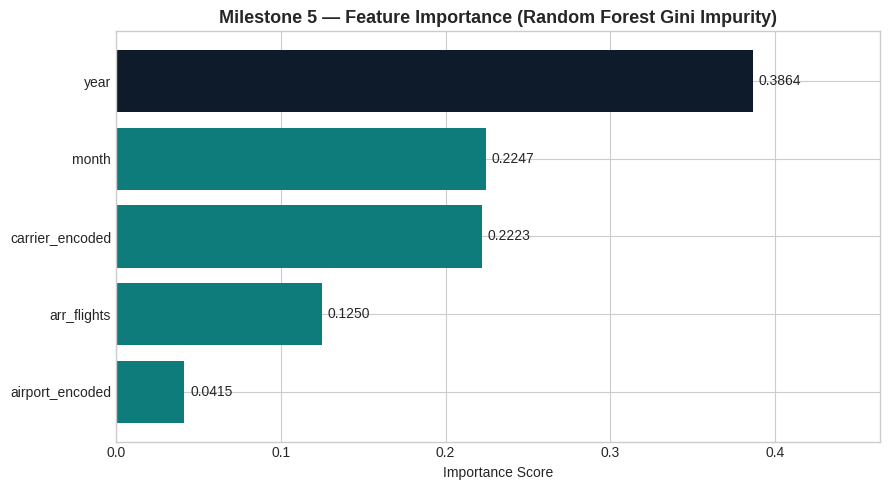

Saved: m5_feature_importance.png

  year                 0.3864  ██████████████████████████████████████
  month                0.2247  ██████████████████████
  carrier_encoded      0.2223  ██████████████████████
  arr_flights          0.1250  ████████████
  airport_encoded      0.0415  ████

   MILESTONE 5 — FINAL SUMMARY
  n_estimators (best)  : 70 trees
  max_depth            : 10
-------------------------------------------------------
  Test Accuracy        : 0.7424  (74.24%)
  AUC-ROC              : 0.8199
  Weighted Precision   : 0.7427
  Weighted Recall      : 0.7424
  Weighted F1-Score    : 0.7425
-------------------------------------------------------
  Confusion Matrix:
    TN=9,847  FP=4,360  FN=4,462  TP=15,576

📁 Milestone 5 outputs:
   m5_confusion_matrix.png   ← Confusion matrix on test set
   m5_roc_curve.png          ← ROC curve + optimal threshold
   m5_feature_importance.png ← Feature importance bar chart
   milestone5_summary.csv    ← All metrics in one CSV

✅ Milest

In [ ]:
# ============================================================
# MILESTONE 5 — FINAL EVALUATION
# Airline Flight Delay Classifier | KD34403 Group 11
# ============================================================


# ── CELL 1: Imports & Load Data ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Load the preprocessed test set (scaled, created in Milestone 1)
test_df   = pd.read_csv('test_preprocessed_scaled.csv')
train_bal = pd.read_csv('train_preprocessed_balanced.csv')

final_features = ['year', 'month', 'carrier_encoded', 'airport_encoded', 'arr_flights']

X_train = train_bal[final_features]
y_train = train_bal['target']
X_test  = test_df[final_features]
y_test  = test_df['target']

print(f'Test set size  : {X_test.shape[0]:,} samples')
print(f'Train set size : {X_train.shape[0]:,} samples')
print()
print('Class distribution (test set):')
print(y_test.value_counts(normalize=True)
      .rename({0: 'Not Delayed (0)', 1: 'Delayed (1)'})
      .round(4))
print()
print('Data loaded successfully ✅')


# ── CELL 2: Train Final Model (or Load from M3) ───────────────
# If you saved the model in Milestone 3, load it directly:
# final_rf = joblib.load('flight_delay_rf_m3.pkl')

# Otherwise, re-train with the best hyperparameters from M3
best_n = 70   # <-- replace with your actual best_n from Milestone 3

final_rf = RandomForestClassifier(
    n_estimators  = best_n,
    max_depth     = 10,
    class_weight  = 'balanced',
    random_state  = SEED
)
final_rf.fit(X_train, y_train)
print(f'Model trained: RandomForest  n_estimators={best_n}  max_depth=10 ✅')


# ── CELL 3: Test Set Predictions ─────────────────────────────
y_pred      = final_rf.predict(X_test)
y_pred_prob = final_rf.predict_proba(X_test)[:, 1]   # probability for class 1 (Delayed)

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_prob)
test_pre = precision_score(y_test, y_pred, average='weighted')
test_rec = recall_score(y_test, y_pred, average='weighted')
test_f1  = f1_score(y_test, y_pred, average='weighted')

print()
print('=' * 50)
print('   MILESTONE 5 — TEST SET RESULTS')
print('=' * 50)
print(f'  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Test AUC-ROC   : {test_auc:.4f}')
print(f'  Precision (wt) : {test_pre:.4f}')
print(f'  Recall    (wt) : {test_rec:.4f}')
print(f'  F1-Score  (wt) : {test_f1:.4f}')
print('=' * 50)
print()
print('--- Full Classification Report (Test Set) ---')
print(classification_report(
    y_test, y_pred,
    target_names=['Not Delayed (0)', 'Delayed (1)']
))


# ── CELL 4: Confusion Matrix ──────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(7, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Not Delayed', 'Delayed']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(
    'Milestone 5 — Confusion Matrix (Test Set)',
    fontsize=14, fontweight='bold'
)

# Annotate TN / FP / FN / TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i - 0.3, labels[i][j],
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('m5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m5_confusion_matrix.png')

# Print raw counts
tn, fp, fn, tp = cm.ravel()
print(f'\nTN (correct Not Delayed) : {tn:,}')
print(f'FP (wrong Delayed)       : {fp:,}   ({fp/len(y_test)*100:.1f}%)')
print(f'FN (missed Delays)       : {fn:,}   ({fn/len(y_test)*100:.1f}%)')
print(f'TP (correct Delayed)     : {tp:,}')


# ── CELL 5: ROC Curve ────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#0E7C7B', linewidth=2.5,
        label=f'Random Forest (AUC = {test_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#0E7C7B')

# Mark the point closest to (0,1) — optimal threshold
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color='red', s=80, zorder=5,
           label=f'Optimal threshold ≈ {thresholds[optimal_idx]:.2f}')

ax.set_title('Milestone 5 — ROC Curve (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('m5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: m5_roc_curve.png')
print(f'Optimal decision threshold : {thresholds[optimal_idx]:.4f}')
print(f'  → TPR at optimal         : {tpr[optimal_idx]:.4f}')
print(f'  → FPR at optimal         : {fpr[optimal_idx]:.4f}')


# ── CELL 6: Feature Importance ───────────────────────────────
importances = final_rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'    : final_features,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#0D1B2A' if v == feat_df['Importance'].max()
          else '#0E7C7B' for v in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)

ax.set_title('Milestone 5 — Feature Importance (Random Forest Gini Impurity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)

plt.tight_layout()
plt.savefig('m5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m5_feature_importance.png')
print()
for _, row in feat_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<20} {row['Importance']:.4f}  {bar}")


# ── CELL 7: Final Summary & Save ─────────────────────────────
summary = pd.DataFrame([{
    'n_estimators'   : best_n,
    'max_depth'      : 10,
    'Test_Accuracy'  : round(test_acc, 4),
    'Test_AUC'       : round(test_auc, 4),
    'Precision_wt'   : round(test_pre, 4),
    'Recall_wt'      : round(test_rec, 4),
    'F1_wt'          : round(test_f1, 4),
    'TN' : int(tn), 'FP' : int(fp),
    'FN' : int(fn), 'TP' : int(tp),
}])
summary.to_csv('milestone5_summary.csv', index=False)

print()
print('=' * 55)
print('   MILESTONE 5 — FINAL SUMMARY')
print('=' * 55)
print(f'  n_estimators (best)  : {best_n} trees')
print(f'  max_depth            : 10')
print('-' * 55)
print(f'  Test Accuracy        : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  AUC-ROC              : {test_auc:.4f}')
print(f'  Weighted Precision   : {test_pre:.4f}')
print(f'  Weighted Recall      : {test_rec:.4f}')
print(f'  Weighted F1-Score    : {test_f1:.4f}')
print('-' * 55)
print(f'  Confusion Matrix:')
print(f'    TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print('=' * 55)
print()
print('📁 Milestone 5 outputs:')
print('   m5_confusion_matrix.png   ← Confusion matrix on test set')
print('   m5_roc_curve.png          ← ROC curve + optimal threshold')
print('   m5_feature_importance.png ← Feature importance bar chart')
print('   milestone5_summary.csv    ← All metrics in one CSV')
print()
print('✅ Milestone 5 complete!')

In [ ]:
# ============================================================
# MILESTONE 5 — ALL VISUALIZATIONS
# Run each cell independently after Cell 3 (predictions done)
# ============================================================


# ── VIZ 1: Confusion Matrix ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Delayed', 'Delayed'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i - 0.3, labels[i][j], ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_title('Milestone 5 — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('m5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 2: ROC Curve ─────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#0E7C7B', linewidth=2.5,
        label=f'Random Forest (AUC = {test_auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#0E7C7B')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=80, zorder=5,
           label=f'Optimal threshold ≈ {thresholds[optimal_idx]:.2f}')
ax.set_title('Milestone 5 — ROC Curve (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('m5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 3: Feature Importance ────────────────────────────────
importances = final_rf.feature_importances_
feat_df = pd.DataFrame({'Feature': final_features,
                         'Importance': importances}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#0D1B2A' if v == feat_df['Importance'].max() else '#0E7C7B'
          for v in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_title('Milestone 5 — Feature Importance (Gini Impurity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('m5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 4: Precision / Recall / F1 Bar Chart ─────────────────
# Compare metrics side-by-side for each class
report = classification_report(y_test, y_pred,
                                target_names=['Not Delayed', 'Delayed'],
                                output_dict=True)
classes  = ['Not Delayed', 'Delayed']
metrics  = ['precision', 'recall', 'f1-score']
labels_m = ['Precision', 'Recall', 'F1-Score']
colors_m = ['#0E7C7B', '#F4A261', '#0D1B2A']

x    = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (m, lbl, col) in enumerate(zip(metrics, labels_m, colors_m)):
    vals = [report[c][m] for c in classes]
    bars = ax.bar(x + i*width, vals, width, label=lbl, color=col, alpha=0.88)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Milestone 5 — Precision / Recall / F1 by Class (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.74, color='gray', linestyle='--', linewidth=1, label='Overall Accuracy')
ax.text(2.45, 0.755, 'Accuracy = 0.74', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('m5_precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()


# ── VIZ 5: Train vs Val vs Test Accuracy Comparison ──────────
fig, ax = plt.subplots(figsize=(7, 5))

split_labels = ['Train\n(74.91%)', 'Validation\n(75.04%)', 'Test\n(74.24%)']
split_values = [0.7491, 0.7504, 0.7424]
bar_colors   = ['#0E7C7B', '#0E7C7B', '#0D1B2A']

bars = ax.bar(split_labels, split_values, color=bar_colors,
              width=0.45, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')

ax.set_ylim(0.70, 0.78)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Milestone 5 — Train vs Validation vs Test Accuracy',
             fontsize=13, fontweight='bold')
ax.axhline(0.7424, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(2.3, 0.744, 'Test baseline', fontsize=9, color='red', alpha=0.8)

# Gap annotation
ax.annotate('', xy=(2, 0.7491), xytext=(2, 0.7424),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(2.05, 0.7457, 'gap\n0.0067', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('m5_train_val_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Healthy gap — no overfitting detected ✅')


# ── VIZ 6: Threshold vs Precision & Recall ───────────────────
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pr_thresholds, precision_curve[:-1], color='#0E7C7B',
        linewidth=2, label='Precision')
ax.plot(pr_thresholds, recall_curve[:-1],    color='#F4A261',
        linewidth=2, label='Recall')

# Mark default threshold 0.5
ax.axvline(0.50, color='gray',  linestyle='--', linewidth=1.2, label='Default threshold (0.50)')
# Mark optimal threshold
ax.axvline(thresholds[optimal_idx], color='red', linestyle='--',
           linewidth=1.2, label=f'Optimal threshold ({thresholds[optimal_idx]:.2f})')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Milestone 5 — Precision & Recall vs Decision Threshold',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('m5_threshold_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lower threshold → higher Recall but lower Precision')
print('Raise threshold → higher Precision but lower Recall')


# ── VIZ 7: Error Analysis — FP & FN Breakdown ────────────────
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
total = len(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: pie chart of all predictions
sizes  = [tn, tp, fp, fn]
clabels = ['TN — Correct\nNot Delayed', 'TP — Correct\nDelayed',
           'FP — Wrong\n(Over-predicted)', 'FN — Missed\n(Under-predicted)']
colors_pie = ['#2DC653', '#0E7C7B', '#F4A261', '#E63946']
explode    = (0, 0, 0.05, 0.1)

axes[0].pie(sizes, labels=clabels, colors=colors_pie, explode=explode,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
axes[0].set_title('Test Set — Prediction Breakdown', fontsize=12, fontweight='bold')

# Right: bar showing error types vs correct predictions
categories = ['Correct\n(TN + TP)', 'False Positives\n(FP)', 'False Negatives\n(FN)']
counts     = [tn + tp, fp, fn]
bar_c      = ['#0E7C7B', '#F4A261', '#E63946']

b = axes[1].bar(categories, counts, color=bar_c, width=0.5)
axes[1].bar_label(b, labels=[f'{v:,}\n({v/total*100:.1f}%)' for v in counts],
                  padding=4, fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(counts) * 1.2)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Error Analysis — Correct vs Misclassified',
                  fontsize=12, fontweight='bold')

plt.suptitle('Milestone 5 — Error Analysis (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('m5_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nError Analysis Summary:')
print(f'  Correct predictions  : {tn+tp:,}  ({(tn+tp)/total*100:.1f}%)')
print(f'  False Positives (FP) : {fp:,}  ({fp/total*100:.1f}%) — over-predicted delay')
print(f'  False Negatives (FN) : {fn:,}  ({fn/total*100:.1f}%) — missed real delay')

NameError: name 'plt' is not defined